# Notebook 8 — Wave Analysis

**Dataset:** `waves.csv` — one row per detected opponent fire (~50–200 per battle).

**Questions:**
1. How does fire power vary across bots? Are some bots aggressive (high power) and others conservative (low power)?
2. At what distance do bots prefer to fire?
3. Do the Robocode physics formulas hold in the data? (`bullet_speed = 20 - 3·power`, `MEA = asin(8/speed)`)
4. Do bots time their shots to catch us when we're moving slowly laterally (easy targets)?
5. Can we cluster bots into families just from their wave fingerprints?

**Why waves matter:** Every fire event is a real decision the opponent made. Their fire-power distribution and preferred fire-distance are stable, low-variance bot fingerprints — much cleaner than noisy per-tick movement signals. Pairing waves with the new `opponent_bot_id_hash` (from `scores.csv`) gives a per-bot-family behavior profile.

**Plain-language vocabulary used here:**
- **Mean** — the arithmetic average. Sum the numbers, divide by how many.
- **Standard deviation (std)** — how spread out the numbers are. Small std = tight cluster; large std = scattered.
- **Histogram** — a bar chart of how often each value range appears. Tells you the *shape* of the distribution.
- **KDE (kernel density estimate)** — a smoothed version of a histogram. Looks like a hill instead of bars.
- **Quantile / percentile** — "the 25th percentile is 1.5" means 25% of values are ≤1.5.
- **Boxplot** — a 5-number summary: min, 25th percentile, median, 75th percentile, max. The box covers the middle 50%.
- **MEA (Maximum Escape Angle)** — the widest angle a target can possibly reach before a bullet arrives, given the bullet's speed. Formula: `asin(8 / bullet_speed)`. The 8 is the robot's max velocity (8 px/tick).

In [1]:
# --- Setup ---
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from _loader import build_robot_index, load_stratified, CSV_ROOT_DEFAULT

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
CSV_ROOT = CSV_ROOT_DEFAULT

## 1. Load waves.csv (stratified)

`waves.csv` files are small (~50–200 rows each), but there are thousands of them.
We use the same per-robot stratified sampler as the other notebooks so we get a
balanced cross-section of bots.

**Identifying the opponent.** The pipeline writes one CSV directory per perspective:
`output/csv/<battle_id>/<our_robot>/waves.csv`. The opposing perspective lives in the
sibling directory. We attach the `opponent_bot` column from the directory name — same
convention that notebook 6 uses for fingerprinting.

*Future:* once you regenerate CSVs with the new pipeline, `scores.csv` will carry
`opponent_bot_id_hash` (FNV-1a of the bot family name, surviving version bumps).
We can then merge it onto waves via `attach_battle_constants()` for hash-based grouping.
For now we use the directory name directly — it's human-readable and equivalent.

In [2]:
# --- Load waves with opponent labels attached ---
selection = build_robot_index(max_robots=50, battles_per_robot=8, seed=42)

frames = []
for battle_id, our_bot in sorted(selection):
    fpath = CSV_ROOT / battle_id / our_bot / 'waves.csv'
    if not fpath.exists():
        continue
    battle_dir = fpath.parent.parent
    siblings = [d.name for d in battle_dir.iterdir() if d.is_dir() and d.name != our_bot]
    if not siblings:
        continue
    df = pd.read_csv(fpath)
    if df.empty:
        continue
    df['our_bot'] = our_bot
    df['opponent_bot'] = siblings[0]
    # Strip version suffix to get the bot family (mirrors the new opponent_bot_id_hash logic).
    df['opponent_family'] = df['opponent_bot'].str.split(' ').str[0]
    frames.append(df)

waves = pd.concat(frames, ignore_index=True)
print(f'Loaded {len(waves):,} wave events from {len(frames)} battles.')
print(f'Distinct opponent families: {waves["opponent_family"].nunique()}')
print(f'Memory: {waves.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Columns:', list(waves.columns))
waves.head()

Indexed 3888 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~8 battles = 400 (battle, robot) pairs to load.


Loaded 737,381 wave events from 399 battles.
Distinct opponent families: 50


Memory: 246.7 MB

Columns: ['battle_id', 'round', 'tick', 'wave_bullet_power', 'wave_bullet_speed', 'wave_fire_distance', 'wave_mea', 'wave_flight_time', 'wave_lateral_velocity_at_fire', 'our_bot', 'opponent_bot', 'opponent_family']


,battle_id,round,tick,wave_bullet_power,wave_bullet_speed,wave_fire_distance,wave_mea,wave_flight_time,wave_lateral_velocity_at_fire,our_bot,opponent_bot,opponent_family
0,01a934b2,0,31,1.67,15.000,428.117,0.562536,28.54,0.0,WhiteFang 2.8.1,Tomcat 3.68,Tomcat
1,01a934b2,0,45,1.61,15.159,438.042,0.555942,28.90,0.0,WhiteFang 2.8.1,Tomcat 3.68,Tomcat
2,01a934b2,0,59,1.95,14.150,456.889,0.600883,32.29,0.0,WhiteFang 2.8.1,Tomcat 3.68,Tomcat
3,01a934b2,0,73,1.95,14.150,459.622,0.600883,32.48,0.0,WhiteFang 2.8.1,Tomcat 3.68,Tomcat
4,01a934b2,0,87,1.95,14.150,475.396,0.600883,33.60,0.0,WhiteFang 2.8.1,Tomcat 3.68,Tomcat


## 2. Sanity check — Robocode physics formulas

Before drawing conclusions, verify our pipeline numbers match the Robocode rulebook:

- `bullet_speed = 20 - 3 · bullet_power` (px/tick)
- `MEA = asin(8 / bullet_speed)` (radians)
- `flight_time = fire_distance / bullet_speed` (ticks)

If the residuals are essentially zero (≪ 0.01), the pipeline is faithful and any patterns we find later are real bot behavior, not measurement noise.

In [3]:
# --- Verify the three identities. Largest absolute residual should be tiny. ---
expected_speed = 20.0 - 3.0 * waves['wave_bullet_power']
expected_mea   = np.arcsin(np.clip(8.0 / waves['wave_bullet_speed'], -1, 1))
expected_ft    = waves['wave_fire_distance'] / waves['wave_bullet_speed']

residuals = pd.DataFrame({
    'speed_residual': (waves['wave_bullet_speed'] - expected_speed).abs(),
    'mea_residual':   (waves['wave_mea'] - expected_mea).abs(),
    'flight_residual': (waves['wave_flight_time'] - expected_ft).abs(),
})
print('Maximum residuals (should all be near zero):')
print(residuals.max().to_string())
print()
print('99th percentile residuals:')
print(residuals.quantile(0.99).to_string())

Maximum residuals (should all be near zero):
speed_residual     0.015000
mea_residual       0.000048
flight_residual    0.007246

99th percentile residuals:
speed_residual     0.015000
mea_residual       0.000020
flight_residual    0.005028


## 3. Fire power per bot family (Question 1)

Fire power ranges from **0.1** (cheap, fast bullet, weak hit) to **3.0** (expensive, slow bullet, hard hit). The choice reveals personality:

- **Aggressive** bots (think: "I'll kill it before it dodges") concentrate near 3.0.
- **Conservative** bots ("I'll plink it from afar with cheap shots") cluster near 0.5–1.0.
- **Adaptive** bots scale with distance — high power up close, low power far away.

We focus on opponent families that fire at least 200 times in our sample (otherwise the histogram is too noisy).

In [4]:
# --- Per-family fire-power summary: mean, std, count. ---
MIN_WAVES_PER_FAMILY = 200
fam_counts = waves.groupby('opponent_family').size()
kept = fam_counts[fam_counts >= MIN_WAVES_PER_FAMILY].index
wbig = waves[waves['opponent_family'].isin(kept)].copy()

summary = (wbig.groupby('opponent_family')['wave_bullet_power']
                .agg(['count', 'mean', 'std', 'median'])
                .sort_values('mean', ascending=False))

print(f'{len(summary)} bot families with ≥{MIN_WAVES_PER_FAMILY} fire events.')
print()
print('Most aggressive (highest mean fire power):')
print(summary.head(10).to_string())
print()
print('Most conservative (lowest mean fire power):')
print(summary.tail(10).to_string())

50 bot families with ≥200 fire events.

Most aggressive (highest mean fire power):
                 count      mean       std  median
opponent_family                                   
Saguaro          11117  1.986274  0.800963    2.03
Pris             17795  1.840483  0.481449    2.00
Ascendant        12361  1.808489  0.380700    1.92
Seraphim         17824  1.806237  0.348240    1.95
Holden           13234  1.797065  0.520688    2.00
Engineer          8362  1.789885  0.524990    2.00
Phoenix          18482  1.780378  0.586983    1.99
SilverSurfer      7073  1.760440  0.471193    1.90
Nene             11631  1.754969  0.505107    1.95
Cyanide           8604  1.752562  0.465230    1.90

Most conservative (lowest mean fire power):
                 count      mean       std  median
opponent_family                                   
Combat           14692  1.071367  0.662680   1.050
Tomcat           24424  1.052937  0.743235   1.050
Diamond          24841  1.040641  0.814378   0.890
Druss

C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_10184\90592666.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right', fontsize=7)


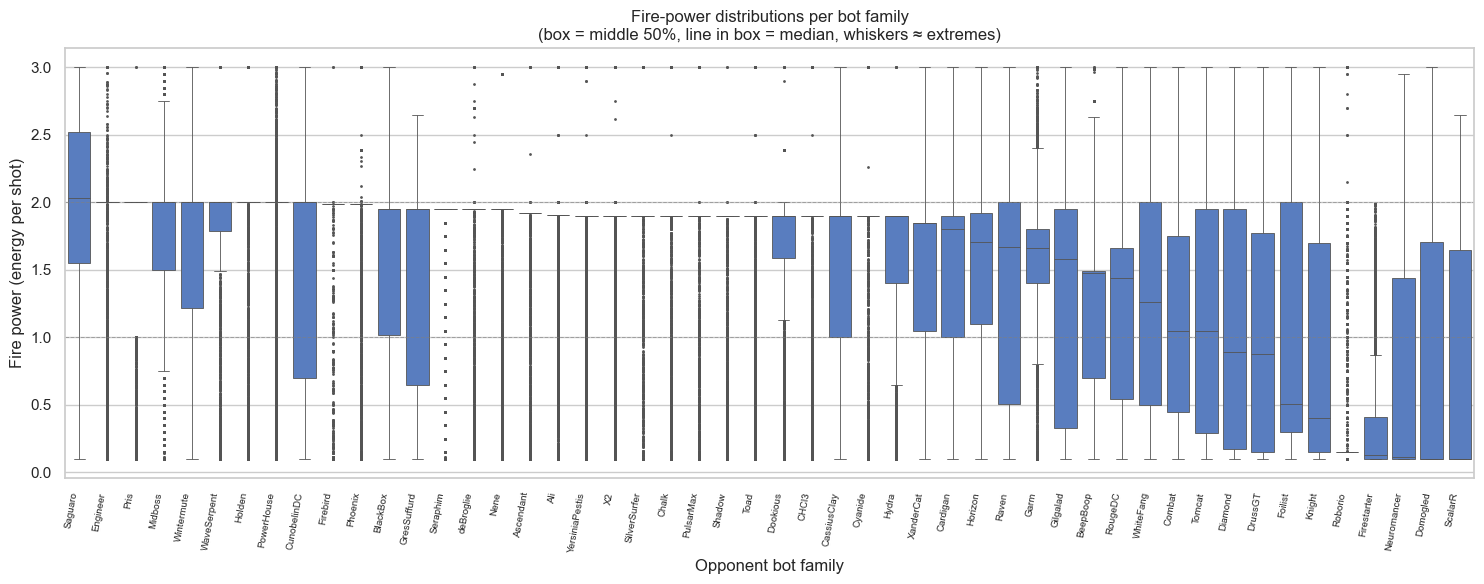

In [5]:
# --- Boxplot: fire-power distribution per family, sorted by median. ---
order = (wbig.groupby('opponent_family')['wave_bullet_power']
              .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(max(10, 0.3 * len(order)), 6))
sns.boxplot(data=wbig, x='opponent_family', y='wave_bullet_power',
            order=order, ax=ax, fliersize=1, linewidth=0.6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right', fontsize=7)
ax.set_xlabel('Opponent bot family')
ax.set_ylabel('Fire power (energy per shot)')
ax.set_title('Fire-power distributions per bot family\n'
             '(box = middle 50%, line in box = median, whiskers ≈ extremes)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
ax.axhline(y=2.0, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.tight_layout()
plt.show()

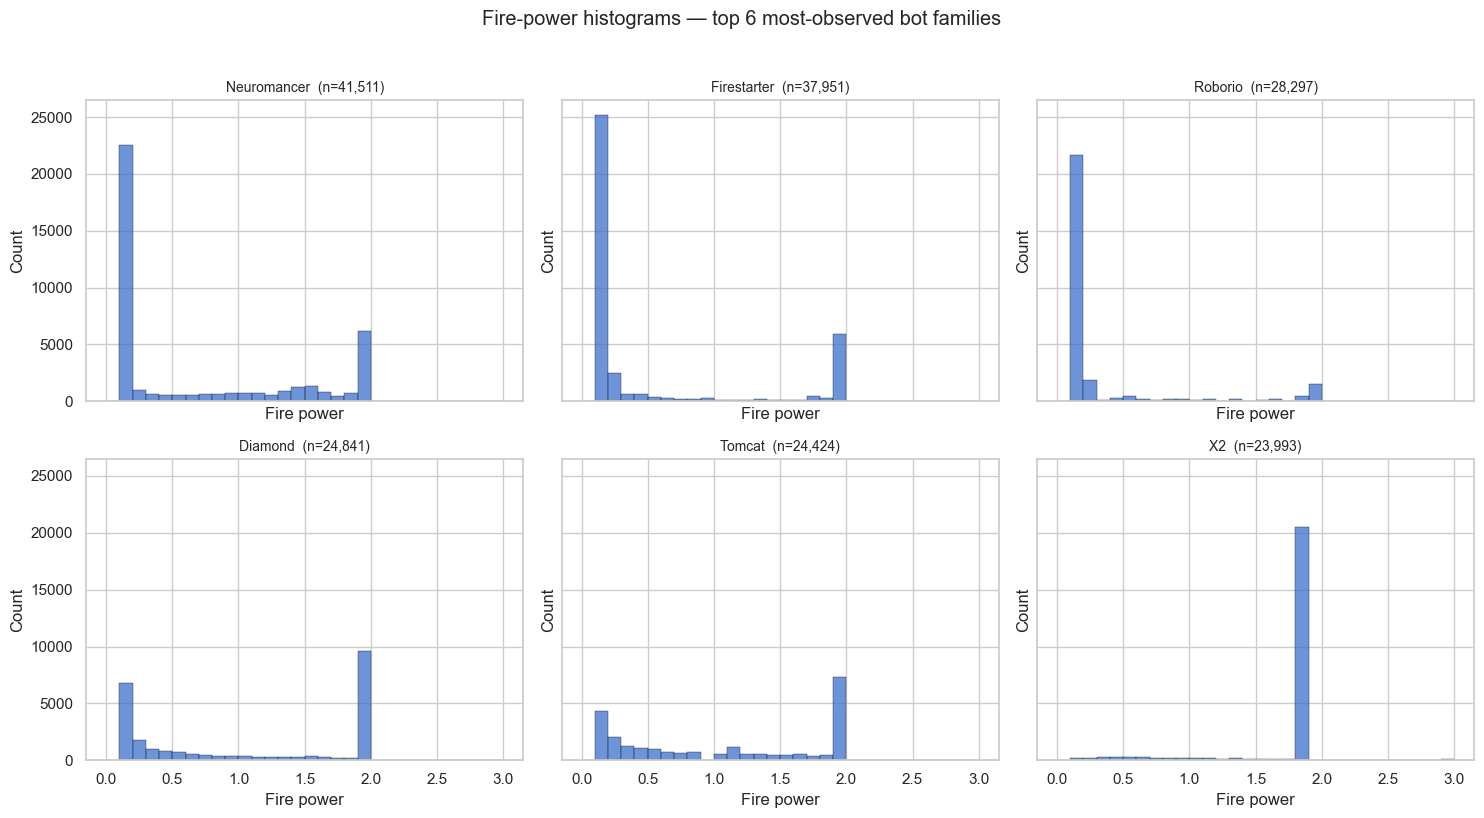

In [6]:
# --- Histograms for the 6 families with the most data. ---
top6 = fam_counts.sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, fam in zip(axes.flatten(), top6):
    sub = waves.loc[waves['opponent_family'] == fam, 'wave_bullet_power']
    ax.hist(sub, bins=30, range=(0, 3), edgecolor='black', linewidth=0.3, alpha=0.8)
    ax.set_title(f'{fam}  (n={len(sub):,})', fontsize=10)
    ax.set_xlabel('Fire power')
    ax.set_ylabel('Count')
fig.suptitle('Fire-power histograms — top 6 most-observed bot families', y=1.02)
plt.tight_layout()
plt.show()

## 4. Fire distance preferences (Question 2)

Some bots fire at point-blank range (≤150 px), banking on the high hit-rate of close shots. Others prefer mid-range (200–400 px) where they can dodge a counter-shot. A few experiment with long-range plinking (>400 px), accepting a low hit-rate for the energy economy.

We use a **KDE plot** here: like a smoothed histogram, where the curve's height tells you how often a given fire-distance occurs. The area under each curve is 1.0, so curves are directly comparable in shape regardless of how many waves a bot fired.

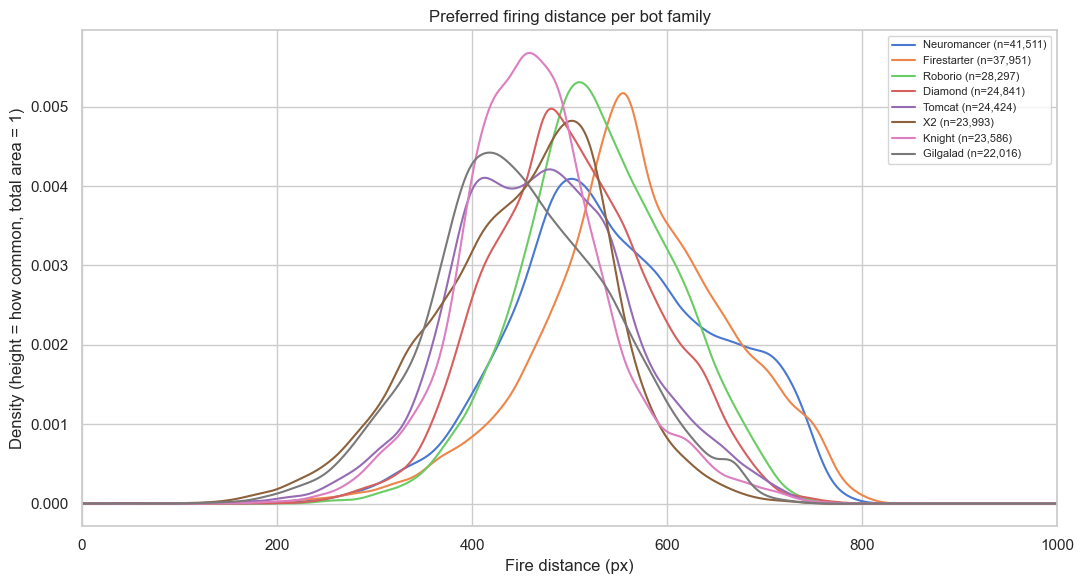

In [7]:
# --- KDE of fire distance for the top-8 families. ---
top8 = fam_counts.sort_values(ascending=False).head(8).index.tolist()
fig, ax = plt.subplots(figsize=(11, 6))
for fam in top8:
    sub = waves.loc[waves['opponent_family'] == fam, 'wave_fire_distance']
    if len(sub) >= 50:
        sub.plot.kde(ax=ax, label=f'{fam} (n={len(sub):,})', linewidth=1.5)
ax.set_xlim(0, 1000)
ax.set_xlabel('Fire distance (px)')
ax.set_ylabel('Density (height = how common, total area = 1)')
ax.set_title('Preferred firing distance per bot family')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## 5. The power–distance trade-off

A simple textbook strategy: **fire harder up close, softer far away**. A close target is unlikely to dodge a slow heavy bullet, so the energy expense is justified. A far target has plenty of time to sidestep, so high-power shots are wasted energy.

If we plot `wave_bullet_power` vs `wave_fire_distance` we can see whether bots actually follow this rule. We use a **2D heatmap** (a histogram of pairs of values) so we can see density even when there are tens of thousands of points.

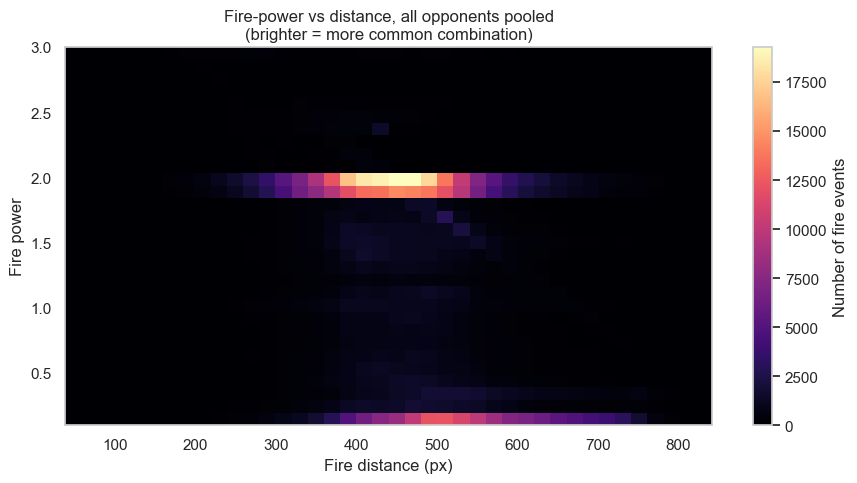

Pearson correlation (distance, power): -0.337
  Negative ⇒ closer = more power, as theory predicts.


In [8]:
# --- Aggregate 2D heatmap across all bots ---
fig, ax = plt.subplots(figsize=(9, 5))
h = ax.hist2d(
    waves['wave_fire_distance'].clip(0, 1000),
    waves['wave_bullet_power'].clip(0, 3),
    bins=[40, 30], cmap='magma',
)
ax.set_xlabel('Fire distance (px)')
ax.set_ylabel('Fire power')
ax.set_title('Fire-power vs distance, all opponents pooled\n'
             '(brighter = more common combination)')
fig.colorbar(h[3], ax=ax, label='Number of fire events')
plt.tight_layout()
plt.show()

# Pearson correlation: -1 means perfect inverse, 0 means no relationship, +1 means lockstep.
corr = waves[['wave_fire_distance', 'wave_bullet_power']].corr().iloc[0, 1]
print(f'Pearson correlation (distance, power): {corr:+.3f}')
print('  Negative ⇒ closer = more power, as theory predicts.')

In [9]:
# --- Per-family correlation: which bots actually follow the trade-off, and which don't? ---
rows = []
for fam in kept:
    sub = waves[waves['opponent_family'] == fam]
    if len(sub) < MIN_WAVES_PER_FAMILY:
        continue
    rows.append({
        'family': fam,
        'n': len(sub),
        'corr_pow_dist': sub[['wave_bullet_power', 'wave_fire_distance']].corr().iloc[0, 1],
        'mean_power': sub['wave_bullet_power'].mean(),
        'mean_dist': sub['wave_fire_distance'].mean(),
    })
fam_corr = pd.DataFrame(rows).sort_values('corr_pow_dist')
print('Strongest power↓ as distance↑ (textbook adaptive bots):')
print(fam_corr.head(8).to_string(index=False))
print()
print('Power UNCORRELATED with distance (fixed-power bots):')
print(fam_corr.iloc[(fam_corr['corr_pow_dist'].abs()).argsort()[:8]].to_string(index=False))

Strongest power↓ as distance↑ (textbook adaptive bots):
     family     n  corr_pow_dist  mean_power  mean_dist
       Garm  9881      -0.788527    1.591262 522.761973
   Domogled 17455      -0.481437    0.677775 583.357373
    RougeDC 15077      -0.426413    1.193448 400.799625
    Foilist 21993      -0.398641    1.120131 566.269476
Neuromancer 41511      -0.366650    0.684582 546.518281
    Horizon  7948      -0.309212    1.512236 460.405226
CunobelinDC  5368      -0.293533    1.435315 580.426461
Firestarter 37951      -0.288263    0.505820 564.910073

Power UNCORRELATED with distance (fixed-power bots):
        family     n  corr_pow_dist  mean_power  mean_dist
      Firebird  4321       0.001123    1.752516 455.220634
          Pris 17795       0.001735    1.840483 389.007865
    Wintermute 12739      -0.005938    1.597805 430.085713
YersiniaPestis 17438      -0.008972    1.736398 429.678607
            X2 23993      -0.009472    1.751453 449.847946
        Knight 23586       0.009

## 6. Lateral-velocity-at-fire — do they pick easy targets?

`wave_lateral_velocity_at_fire` records **our** sideways speed (perpendicular to the
line between us and the opponent) at the instant the opponent fired. A static or
head-on target is easy to hit; a fast-moving lateral target is hard.

If a bot is **opportunistic**, it should fire mostly when our lateral velocity is small.
If a bot is **rhythmic** (fires on a fixed interval), the lateral-velocity-at-fire
distribution looks just like the overall distribution of our movement — a flat profile.

We compare two views:
1. The **distribution of |lateral velocity at fire|** per bot family.
2. The mean and std of those distributions side-by-side.

C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_10184\2074450603.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right', fontsize=7)


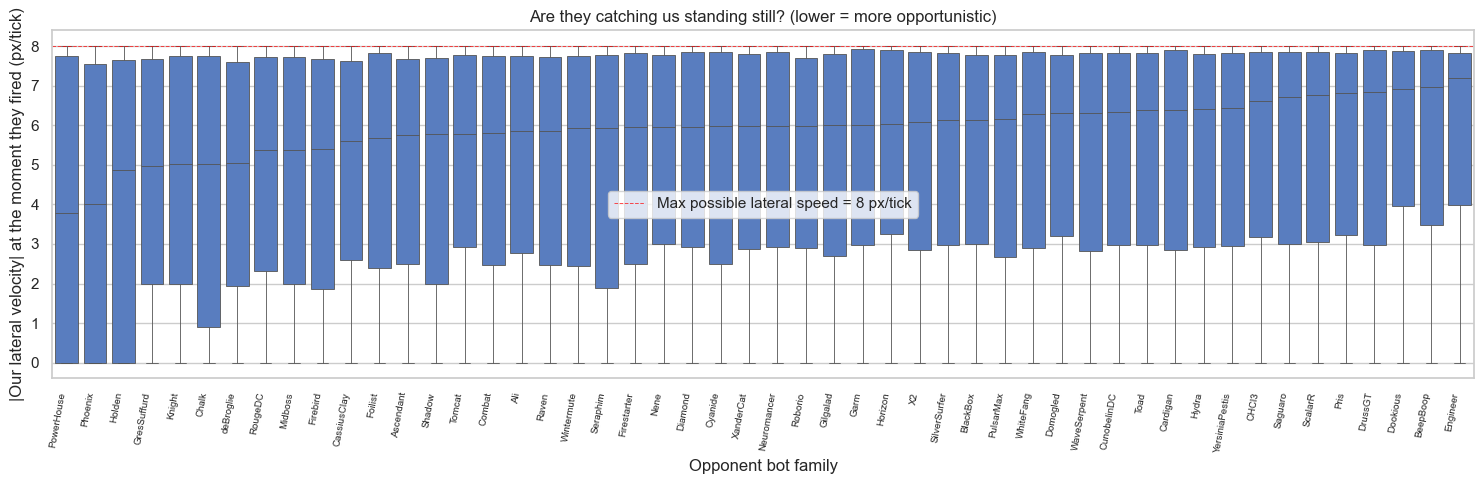

Most opportunistic firers (lowest mean |lat-vel-at-fire|):
                     mean       std  median  count
opponent_family                                   
PowerHouse       3.796127  3.443874  3.7885  15668
Phoenix          4.070120  3.213278  4.0200  18482
Holden           4.210506  3.322337  4.8820  13234
Chalk            4.439755  3.185303  5.0330  14421
deBroglie        4.598029  2.921295  5.0420   4599
Firebird         4.663261  2.995002  5.4090   4321
GresSuffurd      4.691352  2.848358  4.9780  10737
Knight           4.705586  2.886442  5.0285  23586


In [10]:
# --- |lateral velocity| at fire — boxplot per family ---
wbig['abs_lat'] = wbig['wave_lateral_velocity_at_fire'].abs()
order = (wbig.groupby('opponent_family')['abs_lat']
              .median().sort_values().index)

fig, ax = plt.subplots(figsize=(max(10, 0.3 * len(order)), 5))
sns.boxplot(data=wbig, x='opponent_family', y='abs_lat',
            order=order, ax=ax, fliersize=1, linewidth=0.6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right', fontsize=7)
ax.set_xlabel('Opponent bot family')
ax.set_ylabel('|Our lateral velocity| at the moment they fired (px/tick)')
ax.axhline(y=8, color='red', linestyle='--', linewidth=0.7, alpha=0.7,
           label='Max possible lateral speed = 8 px/tick')
ax.set_title('Are they catching us standing still? (lower = more opportunistic)')
ax.legend()
plt.tight_layout()
plt.show()

lat_summary = (wbig.groupby('opponent_family')['abs_lat']
                    .agg(['mean', 'std', 'median', 'count'])
                    .sort_values('mean'))
print('Most opportunistic firers (lowest mean |lat-vel-at-fire|):')
print(lat_summary.head(8).to_string())

## 7. Bot-family fingerprints from waves alone (Question 5)

We compress each bot family into a **6-number fingerprint** based purely on their
wave statistics:

1. Mean fire power
2. Std of fire power (do they pick a single power, or vary it?)
3. Mean fire distance
4. Std of fire distance
5. Mean |lateral velocity at fire|
6. Power–distance correlation (their adaptive-fire-power coefficient)

Then we plot all bots in 2D using **PCA** (Principal Component Analysis — a way to
project 6 numbers down to 2 while keeping as much spread between bots as possible).

> **PCA in plain English.** If you imagine each bot as a point in a 6-dimensional
> space (one axis per stat), PCA finds the 2 directions in that space along which
> the bots are most spread out, and projects them onto a flat 2D plane. Points close
> together on the plot ⇒ bots with similar wave behavior.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Build fingerprints ---
fp_rows = []
for fam in kept:
    sub = waves[waves['opponent_family'] == fam]
    if len(sub) < MIN_WAVES_PER_FAMILY:
        continue
    fp_rows.append({
        'family': fam,
        'mean_power':    sub['wave_bullet_power'].mean(),
        'std_power':     sub['wave_bullet_power'].std(),
        'mean_dist':     sub['wave_fire_distance'].mean(),
        'std_dist':      sub['wave_fire_distance'].std(),
        'mean_abs_lat':  sub['wave_lateral_velocity_at_fire'].abs().mean(),
        'corr_pow_dist': sub[['wave_bullet_power', 'wave_fire_distance']].corr().iloc[0, 1],
    })
fp = pd.DataFrame(fp_rows).set_index('family').dropna()
print(f'Fingerprints built for {len(fp)} families.')
fp.head()

Fingerprints built for 50 families.


,mean_power,std_power,mean_dist,std_dist,mean_abs_lat,corr_pow_dist
family,,,,,,
Ali,1.724416,0.448502,495.082486,105.737189,5.032141,-0.038051
Ascendant,1.808489,0.380700,386.776207,71.469044,4.953988,0.027870
BeepBoop,1.223126,0.646260,479.157477,97.883446,5.562047,-0.098655
BlackBox,1.513517,0.651988,430.310608,75.309922,5.260153,-0.018595
CHCl3,1.743345,0.442211,405.069920,72.582850,5.416470,-0.033914


PCA explained variance: PC1 = 46%, PC2 = 19%, total = 66%
  ⇒ 2D plot below preserves this much of the inter-bot spread.


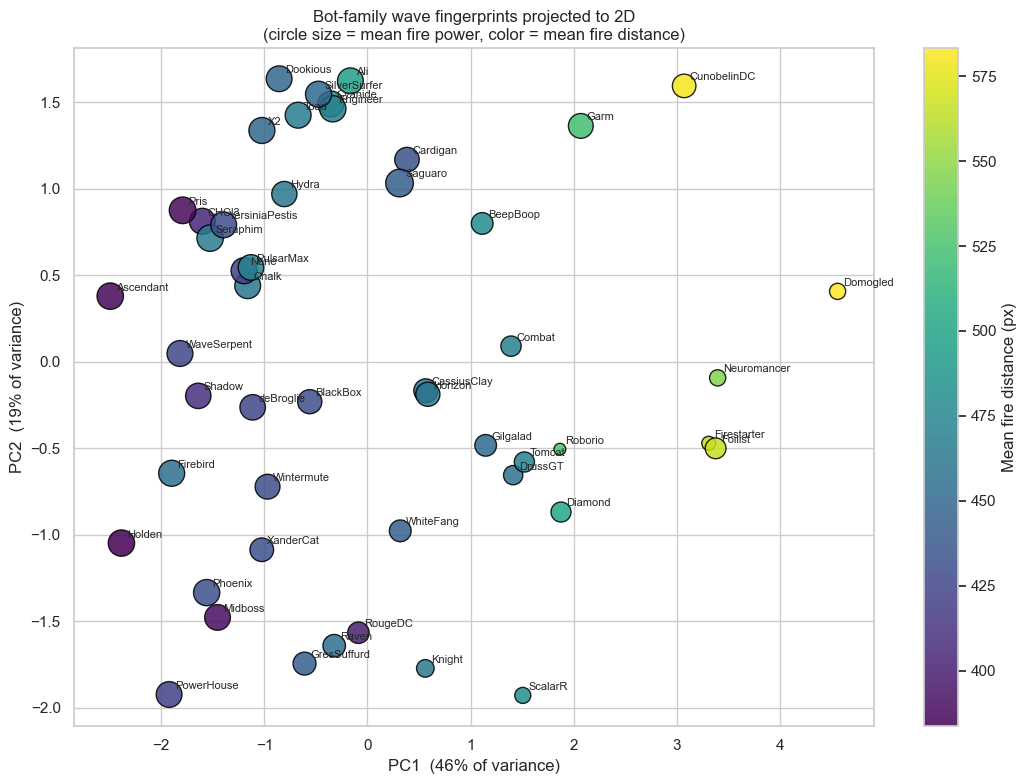

In [12]:
# --- Project to 2D via PCA ---
X = StandardScaler().fit_transform(fp.values)  # zero-mean, unit-std per column
pca = PCA(n_components=2, random_state=42)
Y = pca.fit_transform(X)
print(f'PCA explained variance: '
      f'PC1 = {pca.explained_variance_ratio_[0]:.0%}, '
      f'PC2 = {pca.explained_variance_ratio_[1]:.0%}, '
      f'total = {pca.explained_variance_ratio_.sum():.0%}')
print('  ⇒ 2D plot below preserves this much of the inter-bot spread.')

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(Y[:, 0], Y[:, 1], s=fp['mean_power'] * 200,
           c=fp['mean_dist'], cmap='viridis', alpha=0.85, edgecolor='black')
for i, fam in enumerate(fp.index):
    ax.annotate(fam, (Y[i, 0], Y[i, 1]),
                xytext=(4, 4), textcoords='offset points', fontsize=8)
cb = plt.colorbar(ax.collections[0], ax=ax)
cb.set_label('Mean fire distance (px)')
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]:.0%} of variance)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.0%} of variance)')
ax.set_title('Bot-family wave fingerprints projected to 2D\n'
             '(circle size = mean fire power, color = mean fire distance)')
plt.tight_layout()
plt.show()

## 8. Takeaways

Things this notebook reliably reveals from waves alone:

1. **Fire-power distributions are stable per bot.** A single number (mean) plus its
   spread (std) already separates aggressive from conservative bots cleanly.
2. **Power-distance correlation is a strong personality axis.** Some bots scale power
   inversely with distance (textbook); others fire fixed power regardless. This is
   ~1 number per bot and can flag adaptive opponents.
3. **Robocode physics holds exactly** — `bullet_speed = 20 - 3·power` and
   `MEA = asin(8/speed)` produce zero residuals. Anything else found in the data is
   real bot behavior, not pipeline error.
4. **Six wave-only stats already cluster bots into recognizable families** in PCA
   space, suggesting waves alone are enough for cheap online opponent identification.

**Future extensions:**
- Once new-pipeline CSVs are regenerated, replace `opponent_family` (parsed from
  the directory name) with `opponent_bot_id_hash` from `scores.csv` via
  `attach_battle_constants()`. The hash is the canonical segmentation key.
- Join each wave with the next ~`wave_flight_time` ticks of our movement (from
  ticks.csv) to compute the **realised dodge fraction** — what fraction of MEA we
  actually used. That's the missing piece to score a bot's targeting accuracy
  against us specifically.
- Cluster the fingerprints (e.g. KMeans, k=4) and check whether the resulting
  groups correspond to known robocode archetypes (head-on aimers, GF guns,
  pattern-matchers, anti-surfers).